In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset("titanic")

print("Titanic dataset loaded successfully.")
print("Shape:", df.shape)

Titanic dataset loaded successfully.
Shape: (891, 15)


In [3]:
df.to_csv("titanic.csv", index=False)
print("Saved titanic.csv")

Saved titanic.csv


In [4]:
df.info()
display(df.describe(include="all"))
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
print("Columns with missing values:")
display(missing_percent[missing_percent > 0].to_frame("Missing_Percentage"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Rows: 891
Columns: 15
Columns with missing values:


,Missing_Percentage
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467


In [5]:
df_clean = df.copy()

print("Missing-value percentages before cleaning:")
missing_before = (df_clean.isnull().mean() * 100).sort_values(ascending=False)
display(missing_before[missing_before > 0].to_frame("Missing_Percentage"))

df_clean = df_clean.drop(columns=["deck"])

age_median = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_median)

df_clean = df_clean.dropna(subset=["embarked", "embark_town"])

print("\nMissing-value handling decisions:")
print("- deck: dropped because of high missingness")
print(f"- age: median imputation using {age_median:.2f}")
print("- embarked: rows dropped because missingness is below 5%")
print("- embark_town: rows dropped because missingness is below 5%")

print("\nDataset shape after cleaning:", df_clean.shape)

print("\nMissing values after cleaning:")
display(df_clean.isnull().sum().to_frame("Missing_Count"))

Missing-value percentages before cleaning:


,Missing_Percentage
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467



Missing-value handling decisions:
- deck: dropped because of high missingness
- age: median imputation using 28.00
- embarked: rows dropped because missingness is below 5%
- embark_town: rows dropped because missingness is below 5%

Dataset shape after cleaning: (889, 14)

Missing values after cleaning:


,Missing_Count
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


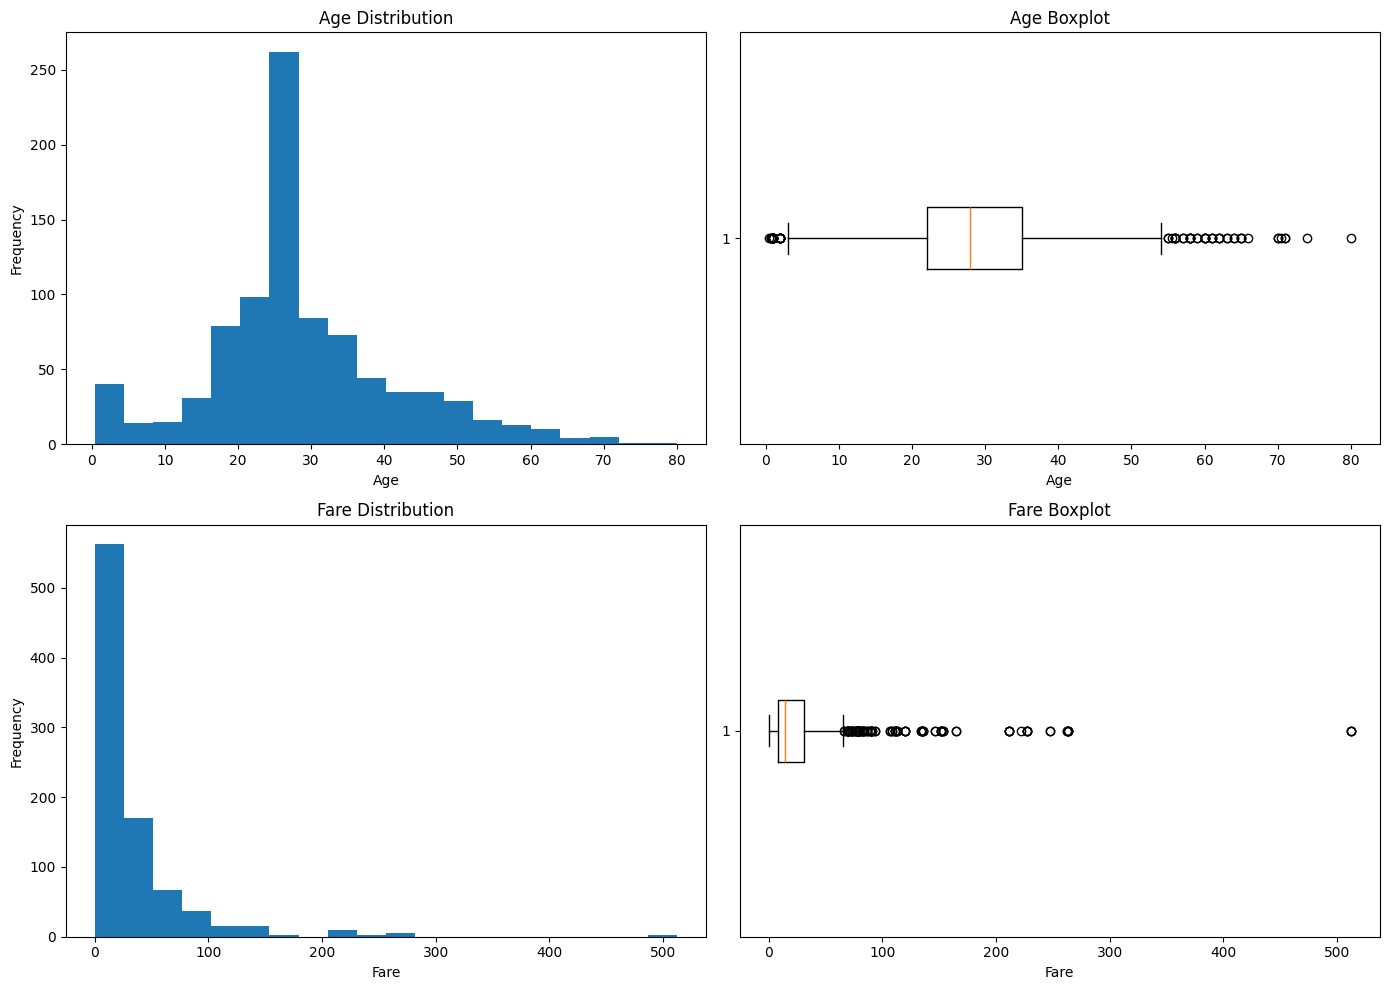

Age outliers: 65
Fare outliers: 114
Mean   : 32.0967
Median : 14.4542
Mode   : 8.0500
Skewness: 4.8014


In [6]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_clean["age"], bins=20)
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].boxplot(df_clean["age"].dropna(), vert=False)
axes[0, 1].set_title("Age Boxplot")
axes[0, 1].set_xlabel("Age")

axes[1, 0].hist(df_clean["fare"], bins=20)
axes[1, 0].set_title("Fare Distribution")
axes[1, 0].set_xlabel("Fare")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].boxplot(df_clean["fare"].dropna(), vert=False)
axes[1, 1].set_title("Fare Boxplot")
axes[1, 1].set_xlabel("Fare")

plt.tight_layout()
plt.show()

def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((series < lower) | (series > upper)).sum()
    return q1, q3, iqr, lower, upper, count

age_q1, age_q3, age_iqr, age_lower, age_upper, age_outliers = iqr_outlier_count(df_clean["age"])
fare_q1, fare_q3, fare_iqr, fare_lower, fare_upper, fare_outliers = iqr_outlier_count(df_clean["fare"])

print(f"Age outliers: {age_outliers}")
print(f"Fare outliers: {fare_outliers}")

fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode().iloc[0]
fare_skew = df_clean["fare"].skew()

print(f"Mean   : {fare_mean:.4f}")
print(f"Median : {fare_median:.4f}")
print(f"Mode   : {fare_mode:.4f}")
print(f"Skewness: {fare_skew:.4f}")

Overall survival rate: 0.3825 (38.25%)

========== SURVIVAL RATE BY SEX ==========
Male survival rate  : 0.1889 (18.89%)
Female survival rate: 0.7404 (74.04%)

========== SURVIVAL RATE BY PCLASS ==========
Class 1: 0.6262 (62.62%)
Class 2: 0.4728 (47.28%)
Class 3: 0.2424 (24.24%)

========== SURVIVAL RATE BY SEX + PCLASS ==========
Female, Class 1: 0.9674 (96.74%)
Female, Class 2: 0.9211 (92.11%)
Female, Class 3: 0.5000 (50.00%)
Male, Class 1: 0.3689 (36.89%)
Male, Class 2: 0.1574 (15.74%)
Male, Class 3: 0.1354 (13.54%)

Female passengers in 1st or 2nd class:
Rows: 168

========== REQUIRED 6-COLUMN CORRELATION MATRIX ==========


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


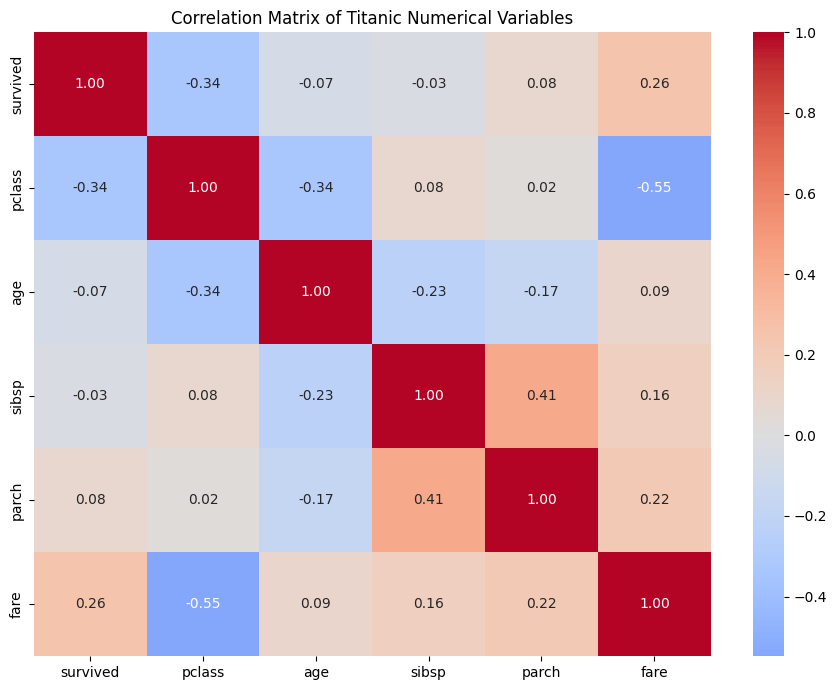


========== TWO STRONGEST OFF-DIAGONAL CORRELATIONS ==========
fare vs pclass: correlation = -0.5482
parch vs sibsp: correlation = 0.4145


In [7]:
overall_survival = df_clean["survived"].mean()
print(f"Overall survival rate: {overall_survival:.4f} ({overall_survival * 100:.2f}%)")

print("\n========== SURVIVAL RATE BY SEX ==========")
male_survival = df_clean.loc[df_clean["sex"] == "male", "survived"].mean()
female_survival = df_clean.loc[df_clean["sex"] == "female", "survived"].mean()

print(f"Male survival rate  : {male_survival:.4f} ({male_survival * 100:.2f}%)")
print(f"Female survival rate: {female_survival:.4f} ({female_survival * 100:.2f}%)")

print("\n========== SURVIVAL RATE BY PCLASS ==========")
for pclass in sorted(df_clean["pclass"].unique()):
    rate = df_clean.loc[df_clean["pclass"] == pclass, "survived"].mean()
    print(f"Class {pclass}: {rate:.4f} ({rate * 100:.2f}%)")

print("\n========== SURVIVAL RATE BY SEX + PCLASS ==========")
for sex in ["female", "male"]:
    for pclass in sorted(df_clean["pclass"].unique()):
        rate = df_clean.loc[
            (df_clean["sex"] == sex) & (df_clean["pclass"] == pclass),"survived"].mean()
        print(f"{sex.capitalize()}, Class {pclass}: {rate:.4f} ({rate * 100:.2f}%)")


female_first_second = df_clean.loc[
    (df_clean["sex"] == "female") &
    ((df_clean["pclass"] == 1) | (df_clean["pclass"] == 2))
]

print("\nFemale passengers in 1st or 2nd class:")
print("Rows:", len(female_first_second))


corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df_clean[corr_columns].corr()

print("\n========== REQUIRED 6-COLUMN CORRELATION MATRIX ==========")
display(corr_matrix)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Titanic Numerical Variables")
plt.tight_layout()
plt.show()

corr_abs = corr_matrix.abs().copy()

for column in corr_abs.columns:
    corr_abs.loc[column, column] = 0

strongest_pairs = (
    corr_abs.stack()
    .sort_values(ascending=False)
)

unique_pairs = []
seen = set()

for (var1, var2), value in strongest_pairs.items():
    pair = tuple(sorted([var1, var2]))
    if pair not in seen:
        seen.add(pair)
        unique_pairs.append((var1, var2, corr_matrix.loc[var1, var2]))
    if len(unique_pairs) == 2:
        break

print("\n========== TWO STRONGEST OFF-DIAGONAL CORRELATIONS ==========")
for var1, var2, value in unique_pairs:
    print(f"{var1} vs {var2}: correlation = {value:.4f}")

### Multivariate Chart Interpretations

**Chart 1 — Survival Rate by Sex and Passenger Class:**  
The chart shows that survival rates differ substantially across both sex and passenger class. Female passengers generally show higher survival rates than male passengers, while passenger class also creates noticeable differences within each sex. This indicates that both sex and class are important variables when examining survival.

**Chart 2 — Age vs Fare by Survival and Sex:**  
The scatter plot shows how age and fare vary together while also separating passengers by survival status and sex. Survivors and non-survivors are distributed across a wide range of ages, while higher fares are concentrated among a smaller number of passengers. The plot also shows that the relationship between age, fare, and survival is not determined by a single variable.

**Chart 3 — Fare Distribution by Passenger Class and Sex:**  
Fare values vary strongly across passenger classes, with higher-class passengers generally paying higher fares. The distribution also differs between male and female passengers within the same class. This demonstrates that passenger class and sex are associated with different fare distributions.

**Chart 4 — Survival Rate by Age Group, Sex, and Passenger Class:**  
Survival rates vary across age groups, sex, and passenger class rather than following one uniform pattern. The differences between male and female passengers remain visible across several age groups, while passenger class introduces additional variation. This highlights the combined effect of demographic and socioeconomic variables on survival.


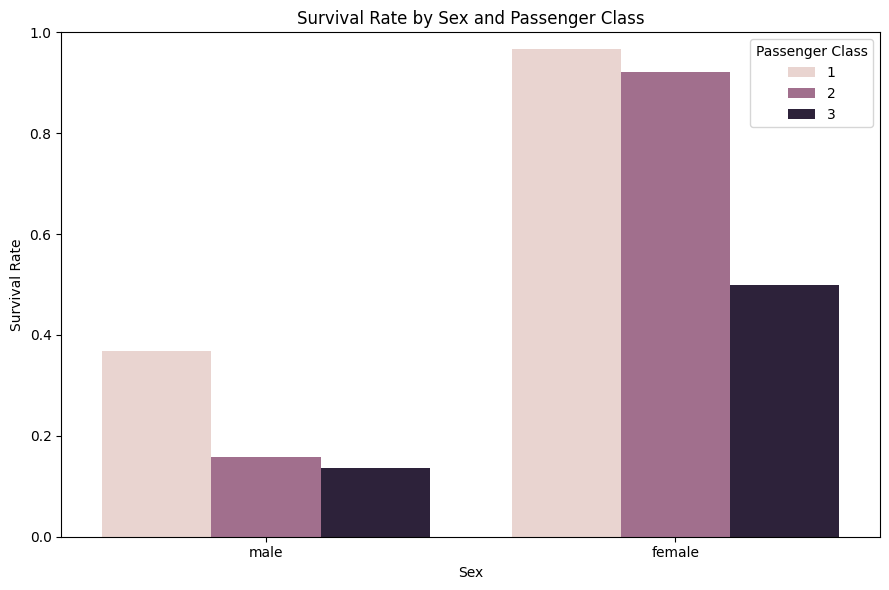

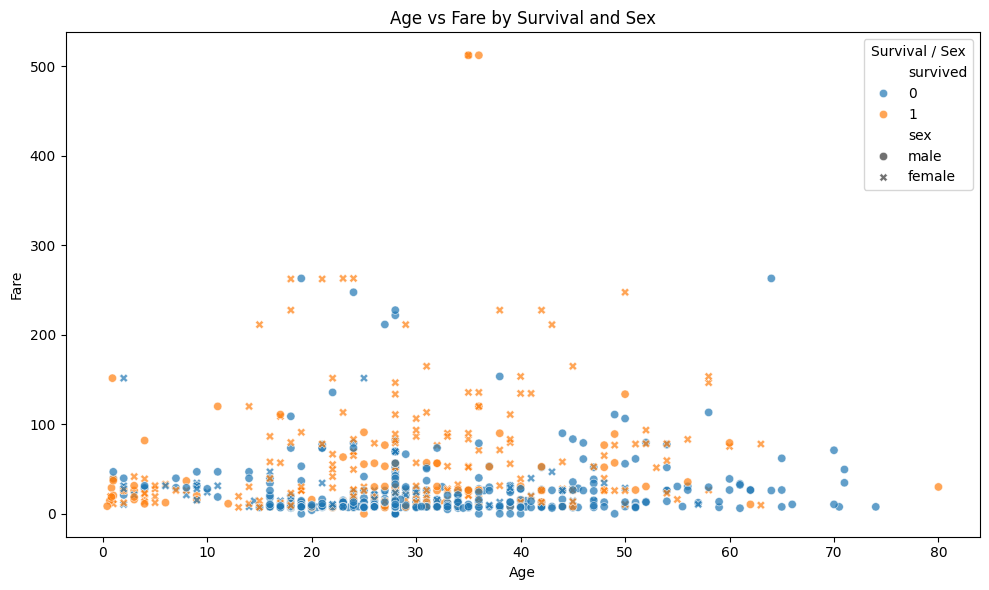

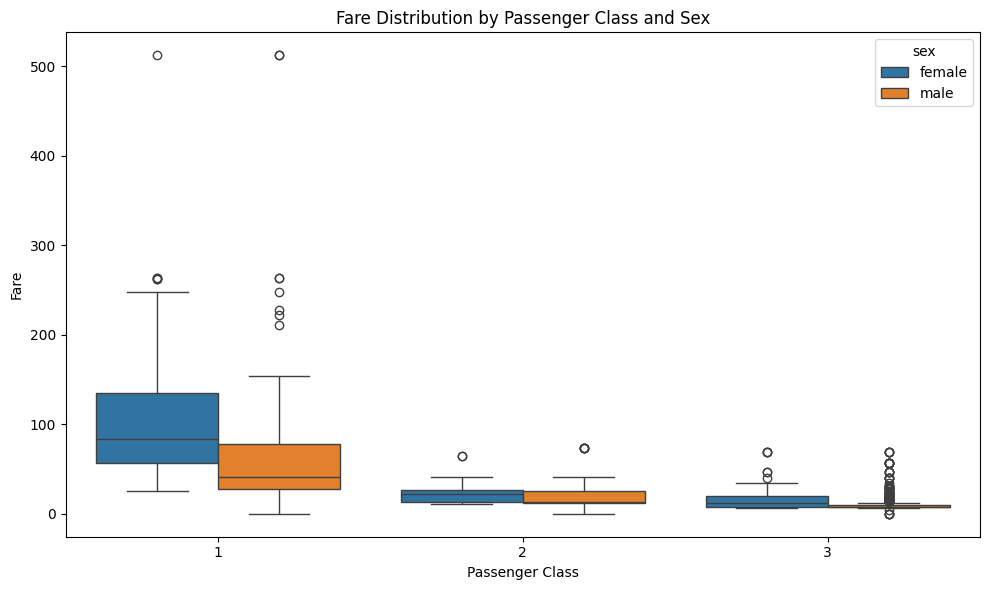

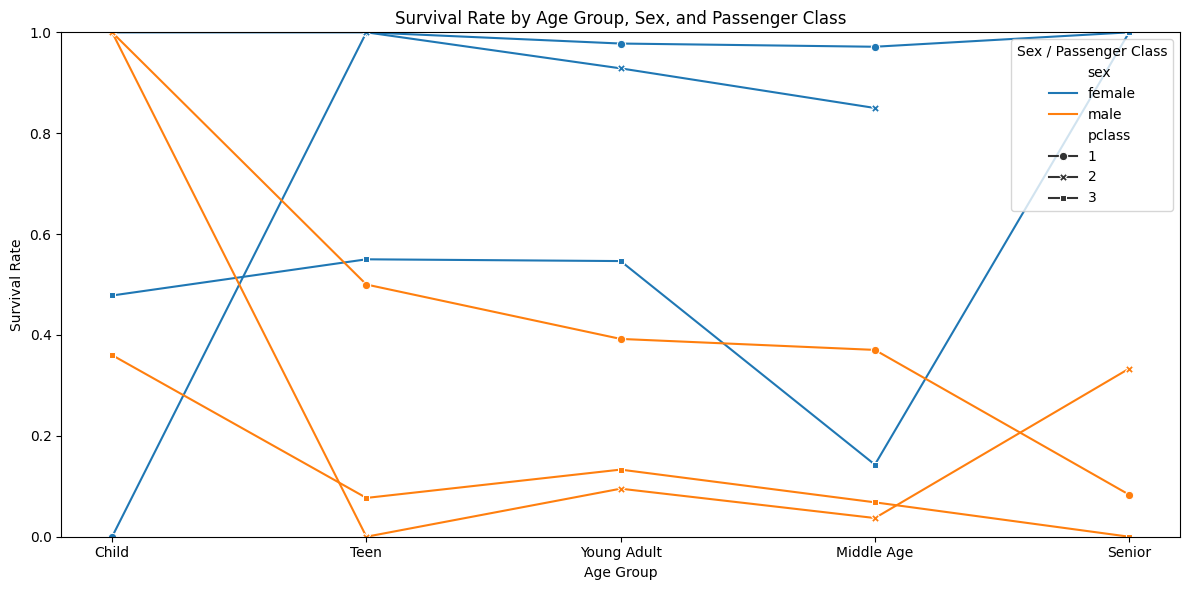

In [8]:
# MULTIVARIATE EDA — 4 DISTINCT CHARTS

# Chart 1: Survival rate by Sex and Passenger Class
plt.figure(figsize=(9, 6))

sns.barplot(
    data=df_clean,
    x="sex",
    y="survived",
    hue="pclass",
    errorbar=None
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.legend(title="Passenger Class")
plt.tight_layout()
plt.show()


# Chart 2: Age vs Fare colored by Survival and styled by Sex
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    alpha=0.7
)

plt.title("Age vs Fare by Survival and Sex")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survival / Sex")
plt.tight_layout()
plt.show()


# Chart 3: Fare distribution by Passenger Class, Sex, and Survival
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="pclass",
    y="fare",
    hue="sex"
)

plt.title("Fare Distribution by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()


# Chart 4: Survival rate across Age Groups by Sex and Passenger Class
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Middle Age", "Senior"]
)

survival_age = (
    df_clean
    .groupby(["age_group", "sex", "pclass"], observed=True)["survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=survival_age,
    x="age_group",
    y="survived",
    hue="sex",
    style="pclass",
    markers=True,
    dashes=False
)

plt.title("Survival Rate by Age Group, Sex, and Passenger Class")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.legend(title="Sex / Passenger Class")
plt.tight_layout()
plt.show()

In [9]:
df_clean["age_group"]

0      Young Adult
1       Middle Age
2      Young Adult
3      Young Adult
4      Young Adult
          ...     
886    Young Adult
887    Young Adult
888    Young Adult
889    Young Adult
890    Young Adult
Name: age_group, Length: 889, dtype: category
Categories (5, object): ['Child' < 'Teen' < 'Young Adult' < 'Middle Age' < 'Senior']

In [11]:
#STANDARDIZATION 

from sklearn.preprocessing import StandardScaler

standardize_cols = ["age", "fare"]

print("\n========== BEFORE STANDARDIZATION ==========")
print("Age mean   :", df_clean["age"].mean())
print("Age std    :", df_clean["age"].std())
print("Fare mean  :", df_clean["fare"].mean())
print("Fare std   :", df_clean["fare"].std())


scaler = StandardScaler()

df_standardized = df_clean.copy()

df_standardized[standardize_cols] = scaler.fit_transform(df_standardized[standardize_cols])


print("\n========== AFTER STANDARDIZATION ==========")
print("Age mean   :", df_standardized["age"].mean())
print("Age std    :", df_standardized["age"].std())
print("Fare mean  :", df_standardized["fare"].mean())
print("Fare std   :", df_standardized["fare"].std())

print("\n========== FIRST 5 STANDARDIZED ROWS ==========")
display(df_standardized[standardize_cols].head())



========== BEFORE STANDARDIZATION ==========
Age mean   : 29.315151856017994
Age std    : 12.984932293690775
Fare mean  : 32.09668087739032
Fare std   : 49.697504316707956

========== AFTER STANDARDIZATION ==========
Age mean   : 2.717486278497571e-16
Age std    : 1.0005629046322504
Fare mean  : 1.3987061727561027e-16
Fare std   : 1.0005629046322506

========== FIRST 5 STANDARDIZED ROWS ==========


,age,fare
0,-0.563674,-0.500240
1,0.669217,0.788947
2,-0.255451,-0.486650
3,0.438050,0.422861
4,0.438050,-0.484133
